<a href="https://colab.research.google.com/github/Aditipujari10/Deep_Learning_Lab/blob/main/DL_EXP_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [ ]:
def create_mlp(initializer):
    model = Sequential()

    model.add(Dense(128, activation='relu',
                    kernel_initializer=initializer,
                    input_shape=(784,)))

    model.add(Dense(64, activation='relu',
                    kernel_initializer=initializer))

    model.add(Dense(10, activation='softmax',
                    kernel_initializer=initializer))

    return model

In [ ]:
initializers = {
    "RandomNormal": tf.keras.initializers.RandomNormal(),
    "Xavier (GlorotUniform)": tf.keras.initializers.GlorotUniform(),
    "HeNormal": tf.keras.initializers.HeNormal()
}

history_init = {}

for name, init in initializers.items():
    print(f"\nTraining with {name} Initialization")

    model = create_mlp(init)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=128,
        validation_data=(X_test, y_test),
        verbose=1
    )

    history_init[name] = history



Training with RandomNormal Initialization


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7946 - loss: 0.7990 - val_accuracy: 0.9372 - val_loss: 0.2101
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9443 - loss: 0.1964 - val_accuracy: 0.9573 - val_loss: 0.1436
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9612 - loss: 0.1346 - val_accuracy: 0.9645 - val_loss: 0.1136
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9709 - loss: 0.0997 - val_accuracy: 0.9693 - val_loss: 0.0973
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9780 - loss: 0.0773 - val_accuracy: 0.9720 - val_loss: 0.0882
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9821 - loss: 0.0615 - val_accuracy: 0.9748 - val_loss: 0.0819
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9859 - loss: 0.0489 - val_accuracy: 0.9763 - val_loss: 0.0794
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9892 - loss: 0.0388 - val_accuracy: 0.

In [ ]:
optimizers = {
    "SGD": SGD(learning_rate=0.01),
    "Adam": Adam(learning_rate=0.001)
}

history_opt = {}

for name, opt in optimizers.items():
    print(f"\nTraining with {name} Optimizer")

    model = create_mlp(tf.keras.initializers.HeNormal())

    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=128,
        validation_data=(X_test, y_test),
        verbose=1
    )

    history_opt[name] = history


Training with SGD Optimizer
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5189 - loss: 1.5985 - val_accuracy: 0.8685 - val_loss: 0.5244
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8729 - loss: 0.4907 - val_accuracy: 0.8974 - val_loss: 0.3742
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8969 - loss: 0.3746 - val_accuracy: 0.9086 - val_loss: 0.3231
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9081 - loss: 0.3280 - val_accuracy: 0.9164 - val_loss: 0.2943
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9154 - loss: 0.2997 - val_accuracy: 0.9216 - val_loss: 0.2744
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9209 - loss: 0.2793 - val_accuracy: 0.9259 - val_loss: 0.2591
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9252 - loss: 0.2632 - val_accuracy: 0.9290 - val_loss: 0.2465
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9289 - lo

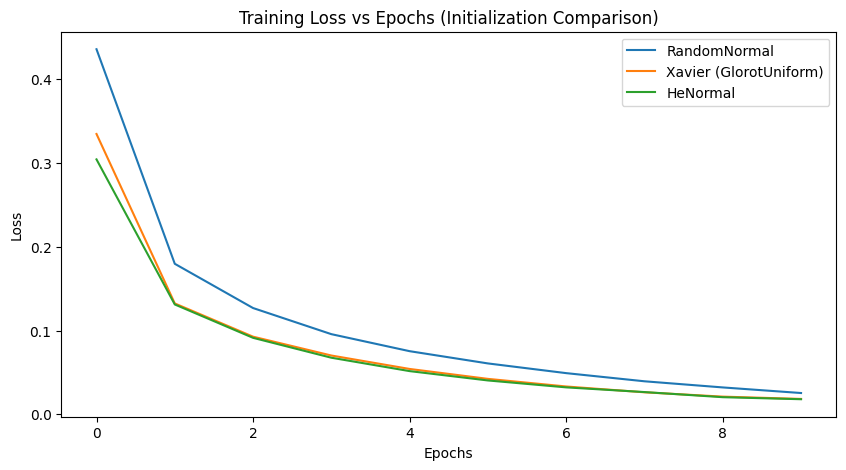

In [ ]:
plt.figure(figsize=(10,5))
for name, history in history_init.items():
    plt.plot(history.history['loss'], label=name)
plt.title("Training Loss vs Epochs (Initialization Comparison)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()




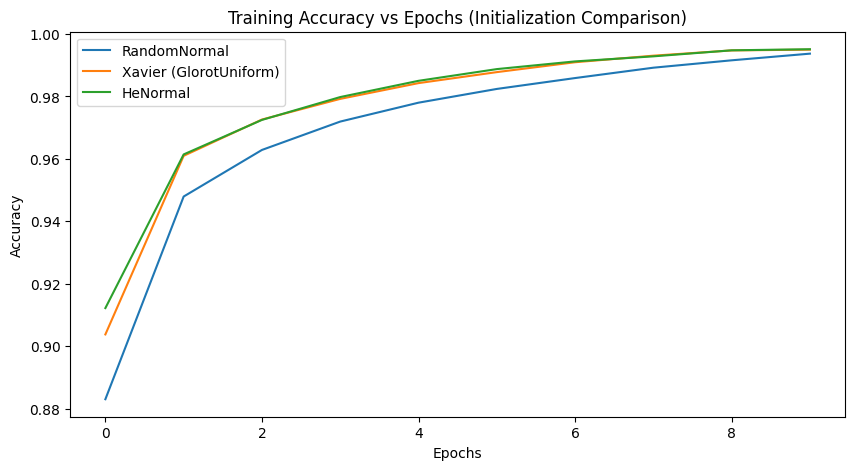

In [ ]:
plt.figure(figsize=(10,5))
for name, history in history_init.items():
    plt.plot(history.history['accuracy'], label=name)
plt.title("Training Accuracy vs Epochs (Initialization Comparison)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

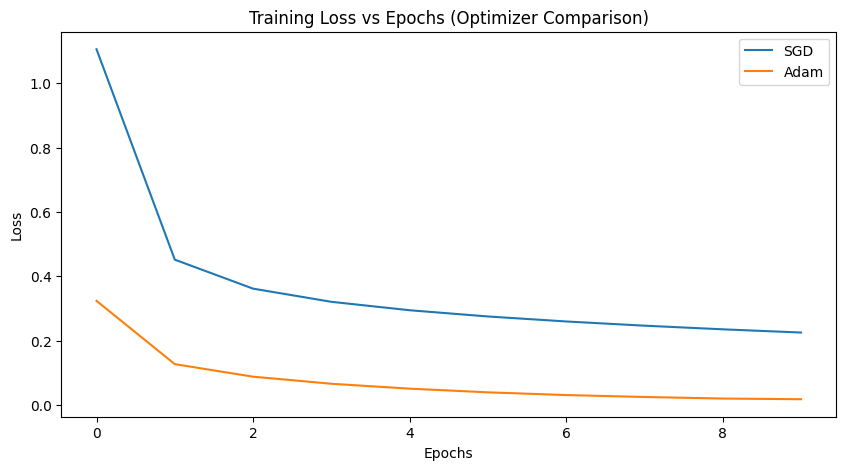

In [ ]:
plt.figure(figsize=(10,5))
for name, history in history_opt.items():
    plt.plot(history.history['loss'], label=name)
plt.title("Training Loss vs Epochs (Optimizer Comparison)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

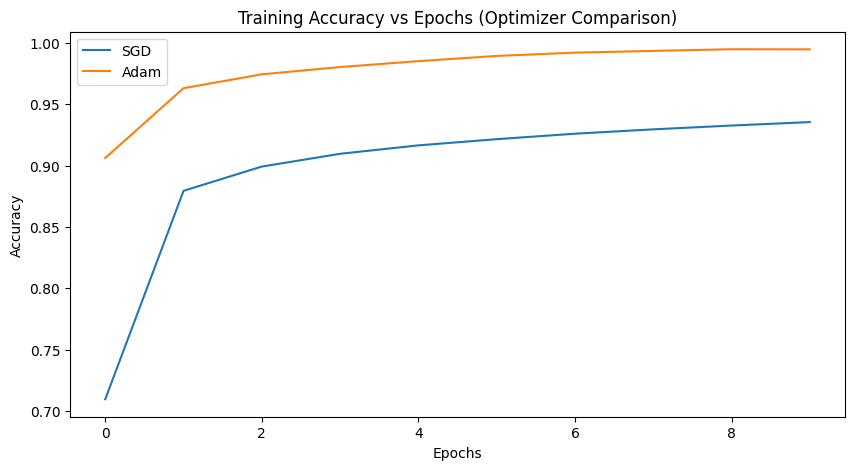

In [ ]:
plt.figure(figsize=(10,5))
for name, history in history_opt.items():
  plt.plot(history.history['accuracy'], label=name)
plt.title("Training Accuracy vs Epochs (Optimizer Comparison)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()